# Small OPCW 分子扩展工具（完整版）

本笔记本用于对输入的 SMILES 分子进行随机突变扩展，生成新的分子结构。

## 功能说明：
1. 读取 TXT 文件中的 SMILES（每行一个，无列名）
2. 对每个 SMILES 进行随机突变（插入/替换/删除原子）
3. **记录所有生成的分子**（包括相似度 < 阈值的分子）
4. 生成三个结果文件：
   - `*_all_molecules.csv`: **所有生成的分子**（包括被相似度过滤掉的）
   - `*_filtered_molecules.csv`: **只包含满足相似度条件的分子**（≥ 阈值）
   - `*_stats.csv`: 每个原始 SMILES 的扩展统计（包含尝试次数、过滤数量等）

## 核心修改：
- ✅ 保持原有生成逻辑和随机种子行为
- ✅ 记录循环中所有化学有效的分子（不管相似度）
- ✅ 区分满足相似度条件的分子和被过滤的分子
- ✅ 使用相同随机种子时，已生成的结果会完全包含在新结果中

## 1. 配置区（可自定义参数）

In [1]:
# ===================== 文件路径配置 =====================
# 输入文件路径（TXT 文件，每行一个 SMILES，无列名）
INPUT_FILE = r"d:\code\stoned-selfies-main\Small_OPCW_Expand\expanded_smiles_all.txt"

# 输出文件夹路径
OUTPUT_DIR = r"d:\code\stoned-selfies-main\Small_OPCW_Expand\Tanimoto_0_1"

# 输出文件名前缀（不包含扩展名）
OUTPUT_PREFIX = "Small_OPCW_expanded_Tanimoto_0_1"


# ===================== 突变参数配置 =====================
# 每个分子的突变步数（1 表示进行 1 次随机操作：插入/替换/删除）
NUM_MUTATIONS = 5

# 每个原始分子生成的突变体数量（严格满足此数量）
NUM_SAMPLES_PER_MOL = 15

# 最大尝试次数（如果尝试此次数仍未达到目标数量，则停止该分子的扩展）
MAX_ATTEMPTS_PER_MOL = 500


# ===================== 相似度筛选配置 =====================
# Tanimoto 相似度阈值（使用 ECFP4 指纹）
# 只保留与原始分子相似度 >= 此值的生成分子
MIN_TANIMOTO_SIMILARITY = 0.4

# 是否启用相似度筛选（True=启用，False=不启用）
ENABLE_SIMILARITY_FILTER = True


# ===================== 分子过滤配置 =====================
# 分子量上限（Da，超过此值的分子将被过滤）
MAX_MOLECULAR_WEIGHT = 500

# 分子量下限（Da，低于此值的分子将被过滤）
MIN_MOLECULAR_WEIGHT = 24

# SELFIES 字符串最大长度（防止生成过大的分子）
MAX_SELFIE_LENGTH = 100

# 是否启用分子量过滤（True=启用，False=不启用）
ENABLE_MW_FILTER = True


# ===================== 自定义突变字母表 =====================
# 定义可用于突变的 SELFIES 符号列表
# 此处使用常见的有机化学原子和结构标记
CUSTOM_ALPHABET = [
    # 基本原子（碳、氮、氧、硫、磷）
    '[C]', '[N]', '[O]', '[S]', '[P]',
    
    # 卤素原子
    '[F]', '[Cl]', '[Br]', '[I]',
    
    # 双键原子
    '[=C]', '[=N]', '[=O]', '[=S]',
    
    # 三键原子
    '[#C]', '[#N]',
    
    # 环结构标记
    '[Ring1]', '[Ring2]', '[Ring3]',
    
    # 分支结构标记
    '[Branch1]', '[Branch2]', '[Branch3]',
]

# 如果设置为 None，则使用 SELFIES 默认的完整字母表
# CUSTOM_ALPHABET = None


# ===================== 其他配置 =====================
# 是否显示详细进度信息
VERBOSE = True

# 随机种子（用于结果可复现，设为 None 则每次结果不同）
RANDOM_SEED = 42

print("✓ 配置完成")
print(f"输入文件: {INPUT_FILE}")
print(f"输出目录: {OUTPUT_DIR}")
print(f"突变步数: {NUM_MUTATIONS}")
print(f"每个分子生成数量: {NUM_SAMPLES_PER_MOL}")
print(f"Tanimoto 相似度阈值: {MIN_TANIMOTO_SIMILARITY}")
print(f"自定义字母表包含: {len(CUSTOM_ALPHABET)} 个符号")


✓ 配置完成
输入文件: d:\code\stoned-selfies-main\Small_OPCW_Expand\expanded_smiles_all.txt
输出目录: d:\code\stoned-selfies-main\Small_OPCW_Expand\Tanimoto_0_1
突变步数: 5
每个分子生成数量: 15
Tanimoto 相似度阈值: 0.4
自定义字母表包含: 21 个符号


## 2. 导入必要的库

**参考来源**: `random_expand_smiles.ipynb` 和 `stoned_selfies_tut.ipynb`

In [2]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import selfies
from selfies import encoder, decoder
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from rdkit.DataStructs.cDataStructs import TanimotoSimilarity
from rdkit import RDLogger

# 禁用 RDKit 警告信息
RDLogger.DisableLog('rdApp.*')

# 设置随机种子
if RANDOM_SEED is not None:
    np.random.seed(RANDOM_SEED)

print("✓ 库导入成功")
print(f"SELFIES 版本: {selfies.__version__}")


✓ 库导入成功
SELFIES 版本: 2.1.1


## 3. 定义核心函数

**参考来源**: 以下函数主要参考自:
- `random_expand_smiles.ipynb` 的 `mutate_selfie()` 函数（第 51-93 行）
- `stoned_selfies_tut.ipynb` 的 `get_selfie_chars()` 和 `sanitize_smiles()` 函数

In [3]:
def get_selfie_chars(selfie):
    """
    将 SELFIES 字符串拆分为字符列表
    
    参数:
        selfie (str): SELFIES 字符串，例如 '[C][=C][C]'
    
    返回:
        list: SELFIES 字符列表，例如 ['[C]', '[=C]', '[C]']
    
    参考: stoned_selfies_tut.ipynb 的 get_selfie_chars() 函数
    """
    chars_selfie = []
    while selfie != '':
        chars_selfie.append(selfie[selfie.find('['): selfie.find(']')+1])
        selfie = selfie[selfie.find(']')+1:]
    return chars_selfie


def sanitize_smiles(smi):
    """
    将 SMILES 字符串标准化并验证其有效性
    
    参数:
        smi (str): SMILES 字符串
    
    返回:
        tuple: (RDKit mol 对象, 标准化的 SMILES, 转换是否成功)
    
    参考: stoned_selfies_tut.ipynb 的 sanitize_smiles() 函数
    """
    try:
        mol = Chem.MolFromSmiles(smi, sanitize=True)
        if mol is None:
            return (None, None, False)
        smi_canon = Chem.MolToSmiles(mol, isomericSmiles=False, canonical=True)
        return (mol, smi_canon, True)
    except:
        return (None, None, False)


def calculate_molecular_weight(mol):
    """
    计算分子的分子量
    
    参数:
        mol: RDKit mol 对象
    
    返回:
        float: 分子量（Da）
    """
    if mol is None:
        return None
    return Descriptors.MolWt(mol)


def get_ECFP4(mol):
    """
    计算分子的 ECFP4 (Morgan) 指纹
    
    参数:
        mol: RDKit mol 对象
    
    返回:
        RDKit 指纹对象
    
    参考: stoned_selfies_tut.ipynb 的 get_ECFP4() 函数
    """
    if mol is None:
        return None
    return AllChem.GetMorganFingerprint(mol, 2)


def calculate_tanimoto_similarity(mol1, mol2):
    """
    计算两个分子之间的 Tanimoto 相似度（使用 ECFP4 指纹）
    
    参数:
        mol1: RDKit mol 对象
        mol2: RDKit mol 对象
    
    返回:
        float: Tanimoto 相似度 (0-1 之间)
    
    参考: stoned_selfies_tut.ipynb 的 get_fp_scores() 函数
    """
    if mol1 is None or mol2 is None:
        return 0.0
    
    fp1 = get_ECFP4(mol1)
    fp2 = get_ECFP4(mol2)
    
    if fp1 is None or fp2 is None:
        return 0.0
    
    return TanimotoSimilarity(fp1, fp2)


def mutate_selfie(selfie, max_molecules_len, alphabet, write_fail_cases=False):
    """
    对 SELFIES 字符串进行单次随机突变（插入/替换/删除）
    
    突变规则（等概率 33.3%）:
        1. 插入（Insert）: 在随机位置插入一个随机字符
        2. 替换（Replace）: 将随机位置的字符替换为另一个随机字符
        3. 删除（Delete）: 删除随机位置的字符
    
    参数:
        selfie (str): 待突变的 SELFIES 字符串
        max_molecules_len (int): 允许的最大 SELFIES 字符数
        alphabet (list): 可用于突变的 SELFIES 字符列表
        write_fail_cases (bool): 是否记录失败案例
    
    返回:
        tuple: (突变后的 SELFIES, 标准化的 SMILES)
    
    参考: random_expand_smiles.ipynb 的 mutate_selfie() 函数（第 51-93 行）
    修改点: 添加了自定义字母表参数，增加了分子量过滤
    """
    valid = False
    fail_counter = 0
    chars_selfie = get_selfie_chars(selfie)
    
    while not valid:
        fail_counter += 1
        
        # 防止无限循环
        if fail_counter > 1000:
            return (None, None)
        
        # 随机选择操作类型: 1=插入, 2=替换, 3=删除
        choice_ls = [1, 2, 3]
        random_choice = np.random.choice(choice_ls, 1)[0]
        
        # 操作 1: 插入一个随机字符
        if random_choice == 1:
            random_index = np.random.randint(len(chars_selfie) + 1)
            random_character = np.random.choice(alphabet, size=1)[0]
            selfie_mutated_chars = (chars_selfie[:random_index] + 
                                   [random_character] + 
                                   chars_selfie[random_index:])
        
        # 操作 2: 替换一个随机字符
        elif random_choice == 2:
            if len(chars_selfie) == 0:
                continue
            random_index = np.random.randint(len(chars_selfie))
            random_character = np.random.choice(alphabet, size=1)[0]
            if random_index == 0:
                selfie_mutated_chars = [random_character] + chars_selfie[random_index+1:]
            else:
                selfie_mutated_chars = (chars_selfie[:random_index] + 
                                       [random_character] + 
                                       chars_selfie[random_index+1:])
        
        # 操作 3: 删除一个随机字符
        elif random_choice == 3:
            if len(chars_selfie) == 0:
                continue
            random_index = np.random.randint(len(chars_selfie))
            if random_index == 0:
                selfie_mutated_chars = chars_selfie[random_index+1:]
            else:
                selfie_mutated_chars = (chars_selfie[:random_index] + 
                                       chars_selfie[random_index+1:])
        
        # 将字符列表拼接回字符串
        selfie_mutated = "".join(x for x in selfie_mutated_chars)
        
        # 尝试解码为 SMILES 并验证
        try:
            smiles = decoder(selfie_mutated)
            mol, smiles_canon, done = sanitize_smiles(smiles)
            
            # 检查长度限制
            if len(selfie_mutated_chars) > max_molecules_len:
                done = False
            
            # 检查是否为空 SMILES
            if smiles_canon == "":
                done = False
            
            # 检查分子量限制
            if done and ENABLE_MW_FILTER and mol is not None:
                mw = calculate_molecular_weight(mol)
                if mw is not None:
                    if mw > MAX_MOLECULAR_WEIGHT or mw < MIN_MOLECULAR_WEIGHT:
                        done = False
            
            if done:
                valid = True
        except:
            valid = False
    
    return (selfie_mutated, smiles_canon)


def get_mutated_SELFIES(selfie, original_mol, num_mutations, num_samples, alphabet):
    """
    对单个 SELFIES 进行多次突变，生成指定数量的突变体
    
    【修改说明】：
    - 记录所有生成的分子（包括相似度 < 阈值的）
    - 返回两个集合：满足相似度条件的分子 + 所有尝试过的分子及其相似度
    
    参数:
        selfie (str): 原始 SELFIES 字符串
        original_mol: 原始分子的 RDKit mol 对象（用于相似度计算）
        num_mutations (int): 每个样本的突变步数
        num_samples (int): 需要生成的样本数量（严格满足，指满足相似度条件的数量）
        alphabet (list): 可用于突变的字符列表
    
    返回:
        tuple: (满足相似度条件的 SMILES 集合, 所有尝试的分子列表 [(smiles, similarity), ...])
    
    参考: random_expand_smiles.ipynb 的主循环逻辑
    修改点: 
        1. 记录所有生成的分子（不仅仅是满足相似度条件的）
        2. 保持原有的生成逻辑和随机种子行为
    """
    mutated_smiles = set()  # 满足相似度条件的分子
    all_attempts = []  # 所有尝试的分子 [(smiles, similarity), ...]
    
    # 计算最大长度
    str_chars = get_selfie_chars(selfie)
    max_len = min(len(str_chars) + num_mutations * 2, MAX_SELFIE_LENGTH)
    
    # 尝试计数器
    attempt_counter = 0
    
    # 获取原始 SMILES（用于去重）
    original_smiles_canon = Chem.MolToSmiles(original_mol, isomericSmiles=False, canonical=True)
    
    # 循环直到达到目标数量或达到最大尝试次数
    while len(mutated_smiles) < num_samples and attempt_counter < MAX_ATTEMPTS_PER_MOL:
        attempt_counter += 1
        
        # 从原始 SELFIE 开始进行多步突变
        current_selfie = selfie
        valid_mutation = True
        
        for _ in range(num_mutations):
            result = mutate_selfie(current_selfie, max_len, alphabet)
            if result[0] is None:  # 突变失败
                valid_mutation = False
                break
            current_selfie, smiles_canon = result
        
        # 如果突变成功
        if valid_mutation and result[0] is not None and result[1] is not None:
            generated_smiles = result[1]
            
            # 检查是否与原始分子相同
            if generated_smiles == original_smiles_canon:
                continue
            
            # 计算相似度
            generated_mol = Chem.MolFromSmiles(generated_smiles)
            if generated_mol is not None:
                similarity = calculate_tanimoto_similarity(original_mol, generated_mol)
                
                # 【关键修改】：记录所有生成的分子（不管相似度）
                all_attempts.append((generated_smiles, similarity))
                
                # 相似度筛选（用于判断是否达到目标数量）
                if ENABLE_SIMILARITY_FILTER:
                    if similarity >= MIN_TANIMOTO_SIMILARITY:
                        mutated_smiles.add(generated_smiles)
                else:
                    mutated_smiles.add(generated_smiles)
    
    return mutated_smiles, all_attempts


print("✓ 核心函数定义完成")

✓ 核心函数定义完成


## 4. 读取输入文件

In [4]:
# 检查输入文件是否存在
if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(f"输入文件不存在: {INPUT_FILE}")

# 读取 TXT 文件（每行一个 SMILES，无列名）
with open(INPUT_FILE, 'r', encoding='utf-8') as f:
    input_smiles = [line.strip() for line in f if line.strip()]

print(f"✓ 成功读取 {len(input_smiles)} 个 SMILES")
print(f"前 5 个 SMILES 示例:")
for i, smi in enumerate(input_smiles[:5], 1):
    print(f"  {i}. {smi}")

✓ 成功读取 5833 个 SMILES
前 5 个 SMILES 示例:
  1. C#N
  2. CC#N
  3. CC(=CCl)[As](C=CCl)C=CCl
  4. CC(=CCl)[As](Cl)C=CCl
  5. CC(=CCl)[As](Cl)Cl


## 5. 验证输入 SMILES 并转换为 SELFIES

In [5]:
# 存储有效的 (SMILES, SELFIES) 对
valid_molecules = []
invalid_count = 0

print("验证并转换 SMILES...")
for smi in tqdm(input_smiles, desc="处理中"):
    # 验证 SMILES
    mol, smi_canon, is_valid = sanitize_smiles(smi)
    
    if not is_valid or mol is None:
        invalid_count += 1
        if VERBOSE:
            print(f"  警告: 无效的 SMILES 跳过: {smi}")
        continue
    
    # 检查分子量
    if ENABLE_MW_FILTER:
        mw = calculate_molecular_weight(mol)
        if mw is None or mw > MAX_MOLECULAR_WEIGHT or mw < MIN_MOLECULAR_WEIGHT:
            invalid_count += 1
            if VERBOSE:
                print(f"  警告: 分子量超出范围跳过: {smi} (MW={mw:.2f})")
            continue
    
    # 转换为 SELFIES
    try:
        selfie = encoder(smi_canon)
        valid_molecules.append((smi_canon, selfie))
    except:
        invalid_count += 1
        if VERBOSE:
            print(f"  警告: SELFIES 转换失败: {smi}")

print(f"\n✓ 验证完成:")
print(f"  有效分子: {len(valid_molecules)} 个")
print(f"  无效分子: {invalid_count} 个")

验证并转换 SMILES...


处理中: 100%|██████████| 5833/5833 [00:01<00:00, 3118.32it/s]

  警告: 分子量超出范围跳过: N (MW=17.03)

✓ 验证完成:
  有效分子: 5832 个
  无效分子: 1 个


## 6. 准备突变字母表

In [6]:
# 确定使用的字母表
if CUSTOM_ALPHABET is None:
    # 使用 SELFIES 默认的完整字母表
    alphabet = list(selfies.get_semantic_robust_alphabet())
    print(f"使用 SELFIES 默认字母表: {len(alphabet)} 个符号")
else:
    # 使用自定义字母表
    alphabet = CUSTOM_ALPHABET
    print(f"使用自定义字母表: {len(alphabet)} 个符号")

print(f"\n字母表示例（前 20 个）:")
for i, token in enumerate(alphabet[:20], 1):
    print(f"  {i:2d}. {token}")

使用自定义字母表: 21 个符号

字母表示例（前 20 个）:
   1. [C]
   2. [N]
   3. [O]
   4. [S]
   5. [P]
   6. [F]
   7. [Cl]
   8. [Br]
   9. [I]
  10. [=C]
  11. [=N]
  12. [=O]
  13. [=S]
  14. [#C]
  15. [#N]
  16. [Ring1]
  17. [Ring2]
  18. [Ring3]
  19. [Branch1]
  20. [Branch2]


## 7. 执行分子突变扩展

**参考来源**: `random_expand_smiles.ipynb` 的主循环部分（第 104-140 行）

In [7]:
# 存储结果
all_generated_smiles = set()  # 所有满足相似度条件的 SMILES（去重）
all_molecules_data = []  # 所有尝试的分子（包括被过滤的）
filtered_molecules_data = []  # 只包含满足相似度条件的分子
stats_data = []  # 每个原始 SMILES 的统计信息

print(f"\n开始突变扩展...")
print(f"每个分子需生成 {NUM_SAMPLES_PER_MOL} 个满足相似度条件的突变体")
print(f"突变步数: {NUM_MUTATIONS}")
print(f"Tanimoto 相似度阈值: {MIN_TANIMOTO_SIMILARITY}")
print(f"最大尝试次数: {MAX_ATTEMPTS_PER_MOL}")
print(f"【新增】：将记录所有生成的分子，包括相似度 < {MIN_TANIMOTO_SIMILARITY} 的分子\n")

# 统计信息
total_filtered = 0  # 满足相似度条件的分子数
total_all_attempts = 0  # 所有尝试的分子数
failed_molecules = []

for original_smiles, original_selfie in tqdm(valid_molecules, desc="扩展进度"):
    # 获取原始分子的 mol 对象
    original_mol = Chem.MolFromSmiles(original_smiles)
    
    # 将原始 SMILES 也加入结果集
    all_generated_smiles.add(original_smiles)
    
    # 对当前分子进行突变（返回两个值：满足条件的集合 + 所有尝试的列表）
    mutated_set, all_attempts = get_mutated_SELFIES(
        original_selfie,
        original_mol,
        NUM_MUTATIONS, 
        NUM_SAMPLES_PER_MOL, 
        alphabet
    )
    
    # 添加到总集合
    all_generated_smiles.update(mutated_set)
    
    # 统计数量
    num_filtered = len(mutated_set)  # 满足相似度条件的数量
    num_all_attempts = len(all_attempts)  # 所有尝试的数量
    total_filtered += num_filtered
    total_all_attempts += num_all_attempts
    
    # 检查是否达到目标数量
    if num_filtered < NUM_SAMPLES_PER_MOL:
        failed_molecules.append({
            'smiles': original_smiles,
            'target': NUM_SAMPLES_PER_MOL,
            'actual': num_filtered
        })
    
    # 【关键修改】：记录所有尝试的分子
    for generated_smi, similarity in all_attempts:
        all_molecules_data.append({
            'original_smiles': original_smiles,
            'generated_smiles': generated_smi,
            'tanimoto_similarity': round(similarity, 4)
        })
        
        # 如果满足相似度条件，也加入到过滤后的数据中
        if similarity >= MIN_TANIMOTO_SIMILARITY:
            filtered_molecules_data.append({
                'original_smiles': original_smiles,
                'generated_smiles': generated_smi,
                'tanimoto_similarity': round(similarity, 4)
            })
    
    # 统计信息
    num_below_threshold = num_all_attempts - num_filtered  # 相似度 < 阈值的数量
    stats_data.append({
        'original_smiles': original_smiles,
        'num_all_attempts': num_all_attempts,
        'num_filtered': num_filtered,
        'num_below_threshold': num_below_threshold,
        'target_count': NUM_SAMPLES_PER_MOL,
        'success_rate': (num_filtered / NUM_SAMPLES_PER_MOL) * 100 if NUM_SAMPLES_PER_MOL > 0 else 0
    })

print(f"\n✓ 突变扩展完成!")
print(f"  原始分子数: {len(valid_molecules)}")
print(f"  目标生成总数（满足相似度条件）: {len(valid_molecules) * NUM_SAMPLES_PER_MOL}")
print(f"  实际满足相似度条件的分子数: {total_filtered}")
print(f"  所有尝试的分子总数（包括被过滤的）: {total_all_attempts}")
print(f"  被过滤掉的分子数（相似度 < {MIN_TANIMOTO_SIMILARITY}）: {total_all_attempts - total_filtered}")
print(f"  平均每个分子生成（满足条件）: {total_filtered / len(valid_molecules):.2f} 个")
print(f"  平均每个分子尝试（包括被过滤）: {total_all_attempts / len(valid_molecules):.2f} 个")
print(f"  总计去重分子数（含原始分子）: {len(all_generated_smiles)} 个")

if failed_molecules:
    print(f"\n⚠ 未达到目标数量的分子: {len(failed_molecules)} 个")
    if VERBOSE and len(failed_molecules) <= 10:
        print("\n详细信息:")
        for item in failed_molecules:
            print(f"  {item['smiles'][:50]}... 目标={item['target']}, 实际={item['actual']}")


开始突变扩展...
每个分子需生成 15 个满足相似度条件的突变体
突变步数: 5
Tanimoto 相似度阈值: 0.4
最大尝试次数: 500
【新增】：将记录所有生成的分子，包括相似度 < 0.4 的分子



扩展进度: 100%|██████████| 5832/5832 [54:02<00:00,  1.80it/s]  


✓ 突变扩展完成!
  原始分子数: 5832
  目标生成总数（满足相似度条件）: 87480
  实际满足相似度条件的分子数: 79034
  所有尝试的分子总数（包括被过滤的）: 1669792
  被过滤掉的分子数（相似度 < 0.4）: 1590758
  平均每个分子生成（满足条件）: 13.55 个
  平均每个分子尝试（包括被过滤）: 286.32 个
  总计去重分子数（含原始分子）: 75101 个

⚠ 未达到目标数量的分子: 1224 个


## 8. 保存结果文件

**参考来源**: `random_expand_smiles.ipynb` 的文件保存逻辑（第 142-152 行）

In [8]:
# 创建输出文件夹（如果不存在）
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 定义输出文件路径（修改为3个CSV文件）
output_all_molecules_csv = os.path.join(OUTPUT_DIR, f"{OUTPUT_PREFIX}_all_molecules.csv")
output_filtered_molecules_csv = os.path.join(OUTPUT_DIR, f"{OUTPUT_PREFIX}_filtered_molecules.csv")
output_stats_csv = os.path.join(OUTPUT_DIR, f"{OUTPUT_PREFIX}_stats.csv")

print(f"\n开始保存结果文件...")

# 1. 保存所有分子到 CSV（包括相似度 < 0.4 的）
df_all_molecules = pd.DataFrame(all_molecules_data)
df_all_molecules.to_csv(output_all_molecules_csv, index=False, encoding='utf-8')
print(f"✓ 已保存所有分子: {output_all_molecules_csv}")
print(f"  包含 {len(df_all_molecules)} 条记录（所有尝试的分子）")

# 2. 保存过滤后的分子到 CSV（只包含相似度 >= 0.4 的）
df_filtered_molecules = pd.DataFrame(filtered_molecules_data)
df_filtered_molecules.to_csv(output_filtered_molecules_csv, index=False, encoding='utf-8')
print(f"✓ 已保存过滤后分子: {output_filtered_molecules_csv}")
print(f"  包含 {len(df_filtered_molecules)} 条记录（相似度 >= {MIN_TANIMOTO_SIMILARITY}）")

# 3. 保存统计信息到 CSV
df_stats = pd.DataFrame(stats_data)
df_stats.to_csv(output_stats_csv, index=False, encoding='utf-8')
print(f"✓ 已保存统计信息: {output_stats_csv}")
print(f"  包含 {len(df_stats)} 个原始分子的统计数据")

print(f"\n=== 处理完成 ===")
print(f"输出文件夹: {OUTPUT_DIR}")
print(f"\n生成的文件：")
print(f"  1. {os.path.basename(output_all_molecules_csv)} - 所有生成的分子")
print(f"  2. {os.path.basename(output_filtered_molecules_csv)} - 满足相似度条件的分子")
print(f"  3. {os.path.basename(output_stats_csv)} - 统计信息")


开始保存结果文件...
✓ 已保存所有分子: d:\code\stoned-selfies-main\Small_OPCW_Expand\Tanimoto_0_1\Small_OPCW_expanded_Tanimoto_0_1_all_molecules.csv
  包含 1669792 条记录（所有尝试的分子）
✓ 已保存所有分子: d:\code\stoned-selfies-main\Small_OPCW_Expand\Tanimoto_0_1\Small_OPCW_expanded_Tanimoto_0_1_all_molecules.csv
  包含 1669792 条记录（所有尝试的分子）
✓ 已保存过滤后分子: d:\code\stoned-selfies-main\Small_OPCW_Expand\Tanimoto_0_1\Small_OPCW_expanded_Tanimoto_0_1_filtered_molecules.csv
  包含 80836 条记录（相似度 >= 0.4）
✓ 已保存统计信息: d:\code\stoned-selfies-main\Small_OPCW_Expand\Tanimoto_0_1\Small_OPCW_expanded_Tanimoto_0_1_stats.csv
  包含 5832 个原始分子的统计数据

=== 处理完成 ===
输出文件夹: d:\code\stoned-selfies-main\Small_OPCW_Expand\Tanimoto_0_1

生成的文件：
  1. Small_OPCW_expanded_Tanimoto_0_1_all_molecules.csv - 所有生成的分子
  2. Small_OPCW_expanded_Tanimoto_0_1_filtered_molecules.csv - 满足相似度条件的分子
  3. Small_OPCW_expanded_Tanimoto_0_1_stats.csv - 统计信息
✓ 已保存过滤后分子: d:\code\stoned-selfies-main\Small_OPCW_Expand\Tanimoto_0_1\Small_OPCW_expanded_Tanimoto_0_1_filtered_molecules

## 9. 结果统计与可视化

In [9]:
# 显示统计摘要
print("\n=== 结果统计摘要 ===")
print(f"原始分子数量: {len(valid_molecules)}")
print(f"总尝试生成分子数: {len(df_all_molecules)}")
print(f"满足相似度条件的分子数: {len(df_filtered_molecules)}")
print(f"被过滤掉的分子数: {len(df_all_molecules) - len(df_filtered_molecules)}")
print(f"过滤率: {((len(df_all_molecules) - len(df_filtered_molecules)) / len(df_all_molecules) * 100):.2f}%")

print(f"\n平均每个原始分子:")
print(f"  尝试生成: {df_stats['num_all_attempts'].mean():.2f} 个")
print(f"  满足条件: {df_stats['num_filtered'].mean():.2f} 个")
print(f"  被过滤: {df_stats['num_below_threshold'].mean():.2f} 个")
print(f"  平均成功率: {df_stats['success_rate'].mean():.2f}%")

print(f"\n生成数量中位数:")
print(f"  满足条件: {df_stats['num_filtered'].median():.0f}")
print(f"  所有尝试: {df_stats['num_all_attempts'].median():.0f}")

print(f"\n生成数量范围:")
print(f"  满足条件 - 最大值: {df_stats['num_filtered'].max()}, 最小值: {df_stats['num_filtered'].min()}")
print(f"  所有尝试 - 最大值: {df_stats['num_all_attempts'].max()}, 最小值: {df_stats['num_all_attempts'].min()}")

# 显示相似度统计
if 'tanimoto_similarity' in df_all_molecules.columns:
    print(f"\n=== Tanimoto 相似度统计（所有分子） ===")
    print(f"平均相似度: {df_all_molecules['tanimoto_similarity'].mean():.4f}")
    print(f"中位数相似度: {df_all_molecules['tanimoto_similarity'].median():.4f}")
    print(f"最小相似度: {df_all_molecules['tanimoto_similarity'].min():.4f}")
    print(f"最大相似度: {df_all_molecules['tanimoto_similarity'].max():.4f}")
    print(f"\n相似度分布:")
    print(f"  < 0.4: {(df_all_molecules['tanimoto_similarity'] < 0.4).sum()} 个")
    print(f"  >= 0.4: {(df_all_molecules['tanimoto_similarity'] >= 0.4).sum()} 个")
    print(f"  >= 0.5: {(df_all_molecules['tanimoto_similarity'] >= 0.5).sum()} 个")
    print(f"  >= 0.6: {(df_all_molecules['tanimoto_similarity'] >= 0.6).sum()} 个")
    print(f"  >= 0.7: {(df_all_molecules['tanimoto_similarity'] >= 0.7).sum()} 个")
    print(f"  >= 0.8: {(df_all_molecules['tanimoto_similarity'] >= 0.8).sum()} 个")
    print(f"  >= 0.9: {(df_all_molecules['tanimoto_similarity'] >= 0.9).sum()} 个")

if 'tanimoto_similarity' in df_filtered_molecules.columns and len(df_filtered_molecules) > 0:
    print(f"\n=== Tanimoto 相似度统计（过滤后的分子） ===")
    print(f"平均相似度: {df_filtered_molecules['tanimoto_similarity'].mean():.4f}")
    print(f"中位数相似度: {df_filtered_molecules['tanimoto_similarity'].median():.4f}")
    print(f"最小相似度: {df_filtered_molecules['tanimoto_similarity'].min():.4f}")
    print(f"最大相似度: {df_filtered_molecules['tanimoto_similarity'].max():.4f}")

# 显示前 10 个生成数量最多的分子
print("\n=== 满足条件数量最多的前 10 个原始分子 ===")
print(df_stats.nlargest(10, 'num_filtered')[['original_smiles', 'num_all_attempts', 'num_filtered', 'num_below_threshold', 'success_rate']])

# 显示尝试次数最多的分子
print("\n=== 尝试次数最多的前 10 个原始分子 ===")
print(df_stats.nlargest(10, 'num_all_attempts')[['original_smiles', 'num_all_attempts', 'num_filtered', 'num_below_threshold']])

# 显示未达标的分子
unsuccessful = df_stats[df_stats['success_rate'] < 100]
if len(unsuccessful) > 0:
    print(f"\n=== 未达到目标数量的分子: {len(unsuccessful)} 个 ===")
    print("\n最难扩展的前 10 个分子:")
    print(unsuccessful.nsmallest(10, 'success_rate')[['original_smiles', 'num_all_attempts', 'num_filtered', 'target_count', 'success_rate']])


=== 结果统计摘要 ===
原始分子数量: 5832
总尝试生成分子数: 1669792
满足相似度条件的分子数: 80836
被过滤掉的分子数: 1588956
过滤率: 95.16%

平均每个原始分子:
  尝试生成: 286.32 个
  满足条件: 13.55 个
  被过滤: 272.76 个
  平均成功率: 90.35%

生成数量中位数:
  满足条件: 15
  所有尝试: 255

生成数量范围:
  满足条件 - 最大值: 15, 最小值: 0
  所有尝试 - 最大值: 500, 最小值: 41

=== Tanimoto 相似度统计（所有分子） ===
平均相似度: 0.1811
中位数相似度: 0.1667
最小相似度: 0.0000
最大相似度: 0.9286

相似度分布:
  < 0.4: 1588956 个
  >= 0.4: 80836 个
  >= 0.5: 22853 个
  >= 0.6: 5303 个
  >= 0.7: 1173 个
  >= 0.8: 155 个
  >= 0.9: 9 个

=== Tanimoto 相似度统计（过滤后的分子） ===
平均相似度: 0.4733
中位数相似度: 0.4524
最小相似度: 0.4000
最大相似度: 0.9286

=== 满足条件数量最多的前 10 个原始分子 ===
                         original_smiles  num_all_attempts  num_filtered  \
22           CC(C)C(C)CC(=CCl)[As](Cl)Cl               361            15   
23  CC(C)C(C)CC(C)(C)N(C(C)C)P(=O)(Br)Br               289            15   
24  CC(C)C(C)CC(C)(C)N(C(C)C)P(=O)(Cl)Cl               219            15   
25    CC(C)C(C)CC(C)(C)N(C(C)C)P(=O)(I)I               247            15   
26         CC(C)C(C)CC

## 10. 验证生成分子的分子量分布（可选）


=== 分子量分布统计（所有生成的分子） ===
平均分子量: 244.02 Da
中位数分子量: 233.02 Da
最小分子量: 26.04 Da
最大分子量: 499.99 Da
标准差: 82.70 Da

✓ 分子量分布图已保存: d:\code\stoned-selfies-main\Small_OPCW_Expand\Tanimoto_0_1\Small_OPCW_expanded_Tanimoto_0_1_mw_distribution.png

✓ 分子量分布图已保存: d:\code\stoned-selfies-main\Small_OPCW_Expand\Tanimoto_0_1\Small_OPCW_expanded_Tanimoto_0_1_mw_distribution.png


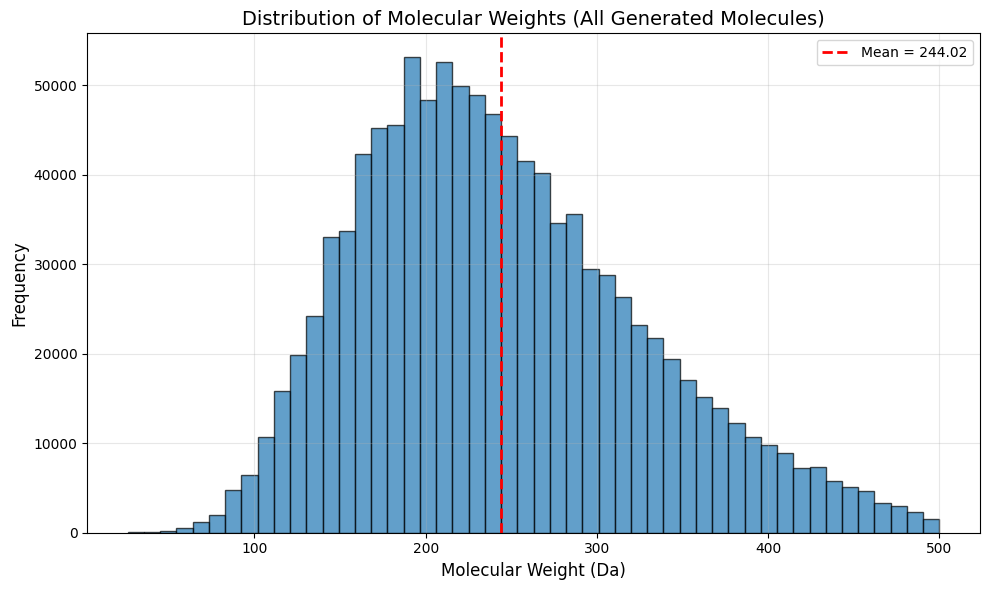

In [10]:
# 计算所有生成分子的分子量（使用 all_molecules_data 中的唯一分子）
all_unique_smiles = set([item['generated_smiles'] for item in all_molecules_data])
molecular_weights = []
for smi in all_unique_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        mw = calculate_molecular_weight(mol)
        if mw is not None:
            molecular_weights.append(mw)

if molecular_weights:
    print("\n=== 分子量分布统计（所有生成的分子） ===")
    print(f"平均分子量: {np.mean(molecular_weights):.2f} Da")
    print(f"中位数分子量: {np.median(molecular_weights):.2f} Da")
    print(f"最小分子量: {np.min(molecular_weights):.2f} Da")
    print(f"最大分子量: {np.max(molecular_weights):.2f} Da")
    print(f"标准差: {np.std(molecular_weights):.2f} Da")
    
    # 绘制分子量分布直方图
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(10, 6))
    plt.hist(molecular_weights, bins=50, edgecolor='black', alpha=0.7)
    plt.xlabel('Molecular Weight (Da)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Distribution of Molecular Weights (All Generated Molecules)', fontsize=14)
    plt.axvline(np.mean(molecular_weights), color='red', linestyle='--', 
                linewidth=2, label=f'Mean = {np.mean(molecular_weights):.2f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # 保存图表
    plot_path = os.path.join(OUTPUT_DIR, f"{OUTPUT_PREFIX}_mw_distribution.png")
    plt.savefig(plot_path, dpi=300)
    print(f"\n✓ 分子量分布图已保存: {plot_path}")
    plt.show()
else:
    print("无法计算分子量分布")

---

## 代码参考说明

本笔记本主要参考了以下文件的代码:

### 1. `random_expand_smiles.ipynb`
- **第 51-93 行**: `mutate_selfie()` 函数 - 核心突变逻辑
- **第 95-103 行**: `get_mutated_SELFIES()` 函数 - 批量突变处理
- **第 104-140 行**: 主循环 - 遍历分子并执行突变
- **第 142-152 行**: 文件保存逻辑

### 2. `stoned_selfies_tut.ipynb`
- **`get_selfie_chars()` 函数**: SELFIES 字符串拆分
- **`sanitize_smiles()` 函数**: SMILES 验证和标准化
- **`get_ECFP4()` 函数**: ECFP4 指纹计算
- **`get_fp_scores()` 函数**: Tanimoto 相似度计算

### 主要修改和优化:
1. **自定义字母表**: 添加了 `CUSTOM_ALPHABET` 参数，允许用户自定义突变原子范围
2. **分子量过滤**: 新增分子量上下限检查
3. **Tanimoto 相似度筛选**: 添加基于 ECFP4 指纹的相似度过滤，只保留相似度 >= 阈值的分子
4. **严格数量控制**: 循环生成直到达到 `NUM_SAMPLES_PER_MOL` 指定的数量，或达到最大尝试次数
5. **配置集中化**: 所有参数集中在第一个单元格
6. **进度显示**: 使用 `tqdm` 显示处理进度
7. **结果统计**: 新增统计分析和可视化功能，包括成功率、相似度分布等
8. **错误处理**: 增强了异常处理和失败重试机制
9. **输出格式**: 按照要求生成三个结果文件，配对文件中包含相似度信息
10. **详细日志**: 显示未达标分子的详细信息，便于调试和参数调整

### 关键逻辑改进:
- **严格满足生成数量**: `get_mutated_SELFIES()` 函数使用 `while` 循环，只有当生成数量达到目标或超过最大尝试次数才停止
- **相似度筛选**: 每个生成的分子都会与原始分子计算 Tanimoto 相似度，只有 >= 阈值的才被保留
- **防止无限循环**: 设置 `MAX_ATTEMPTS_PER_MOL` 参数，避免对难以扩展的分子无限尝试

---
